# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data pandas/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [17]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

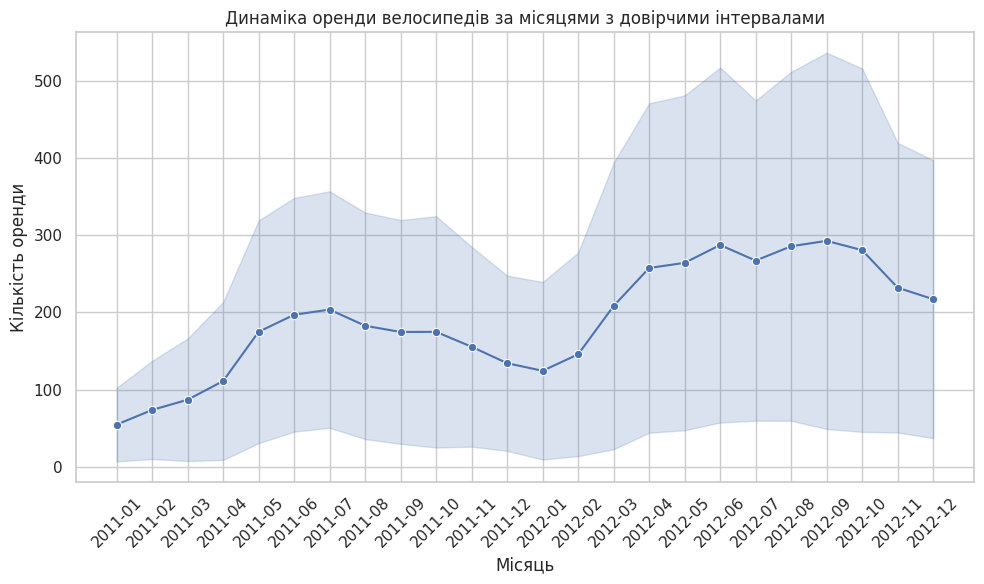

In [18]:
plt.figure(figsize = (10,6))
sns.lineplot(df, x='month_year', y='count', errorbar = 'sd', marker = 'o')
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.xticks(rotation=45)
plt.tight_layout();

Найбільша невизначеність спостерігається у літні місяці 2012 року (06–09) - синя область найбільше розширена

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

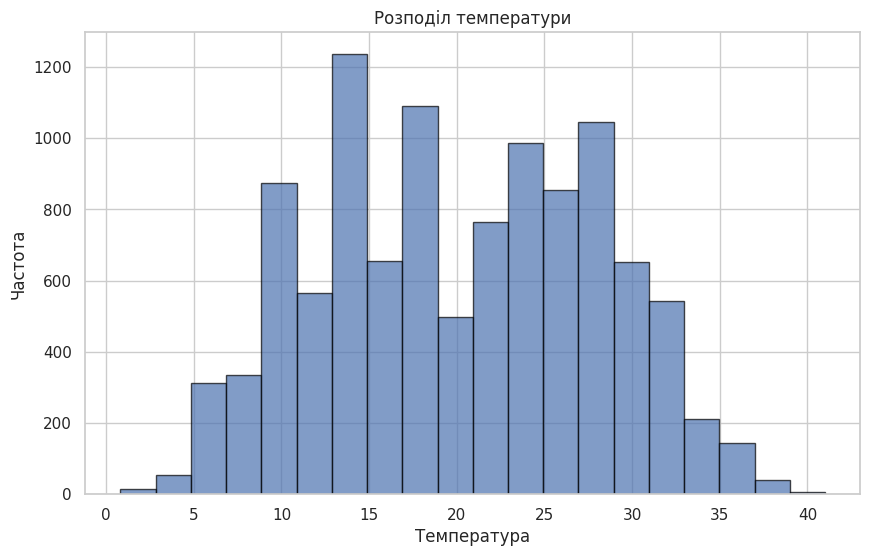

In [22]:
df['temp'].plot.hist(
    bins=20,
    figsize=(10, 6),
    alpha=0.7,
    edgecolor='black',
    title='Розподіл температури',
    xlabel='Температура',
    ylabel='Частота',
)
plt.show()

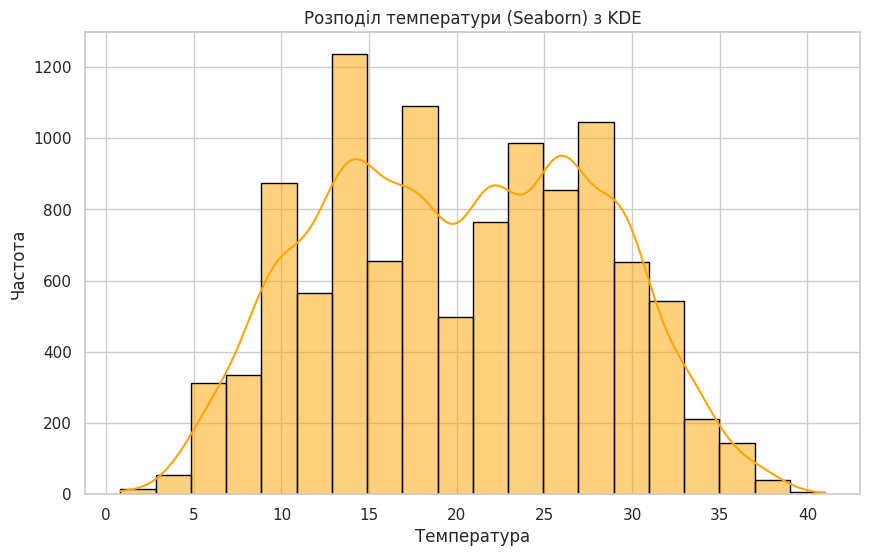

In [24]:
plt.figure(figsize=(10,6))
sns.histplot(df['temp'], bins=20, kde=True, color='orange', edgecolor='black')
plt.title('Розподіл температури (Seaborn) з KDE')
plt.xlabel('Температура')
plt.ylabel('Частота')
plt.show()

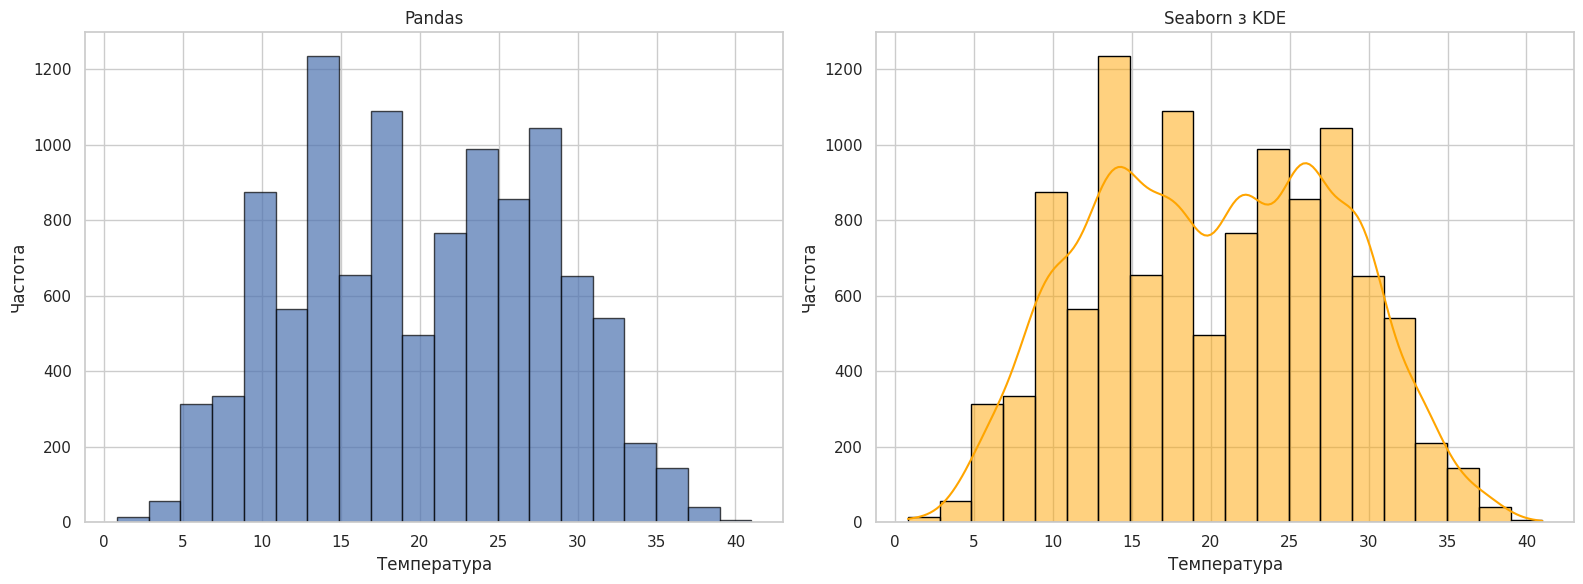

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Гістограма Pandas
df['temp'].plot.hist(
    bins=20,
    alpha=0.7,
    edgecolor='black',
    title='Pandas',
    xlabel='Температура',
    ylabel='Частота',
    ax=axes[0]
)

# Гістограма Seaborn
sns.histplot(
    df['temp'],
    bins=20,
    kde=True,
    color='orange',
    edgecolor='black',
    ax=axes[1]
)
axes[1].set_title('Seaborn з KDE')
axes[1].set_xlabel('Температура')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

1. Pandas показує тільки гістограму (стовпчики), а Seaborn додає ще «гладку криву» (якщо kde=True), яка допомагає бачити форму розподілу більш плавно
2. Ця лінія називається KDE. Вона показує приблизну форму розподілу даних як плавну криву, тобто як би виглядав розподіл, якби ми його згладили

In [40]:
def map_indian_season(month):
    if month in [12, 1, 2]:
        return 1   # Winter
    elif month in [3, 4, 5]:
        return 2   # Summer
    elif month in [6, 7, 8, 9]:
        return 3   # Monsoon
    else:  # 10, 11
        return 4   # Post-monsoon

df['weather_season_india'] = df['month'].apply(map_indian_season)

india_season_names = {
    1: 'Winter',
    2: 'Summer',
    3: 'Monsoon',
    4: 'Post-Monsoon'
}

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

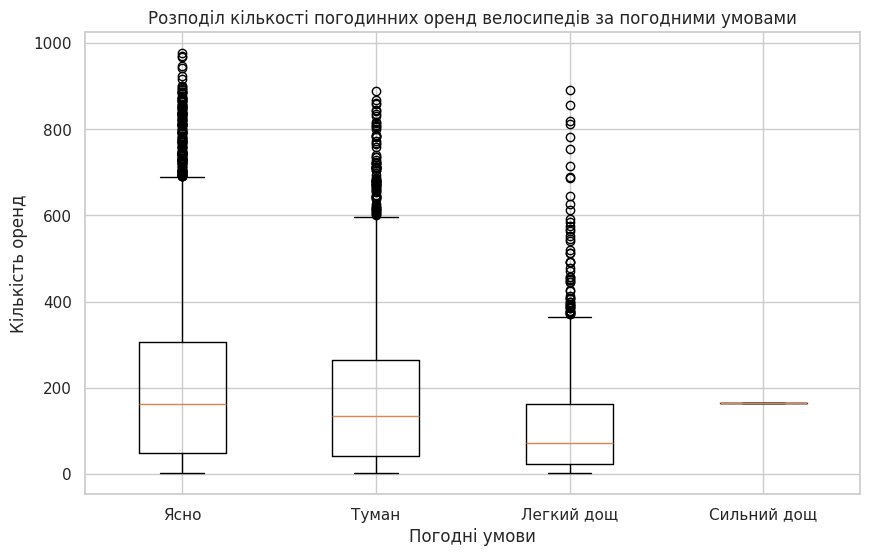

In [33]:
grouped = [df[df['weather'] == w]['count'] for w in sorted(df['weather'].unique())]
weather_labels = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
plt.figure(figsize=(10,6))
plt.boxplot(grouped, tick_labels=weather_labels)
plt.title('Розподіл кількості погодинних оренд велосипедів за погодними умовами')
plt.xlabel('Погодні умови')
plt.ylabel('Кількість оренд')
plt.show()

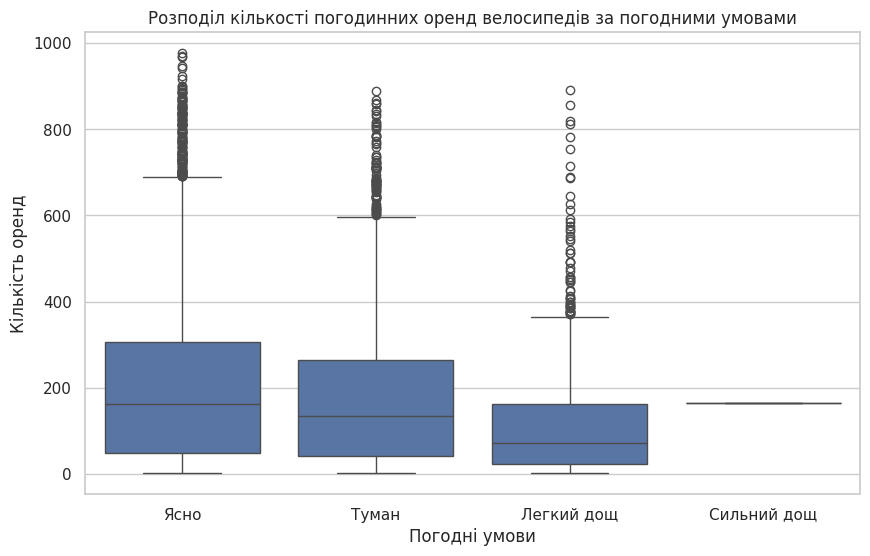

In [34]:
plt.figure(figsize=(10,6))
sns.boxplot(x='weather', y='count', data=df)
plt.title('Розподіл кількості погодинних оренд велосипедів за погодними умовами')
plt.xlabel('Погодні умови')
plt.ylabel('Кількість оренд')
plt.xticks(ticks=[0,1,2,3], labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])
plt.show()

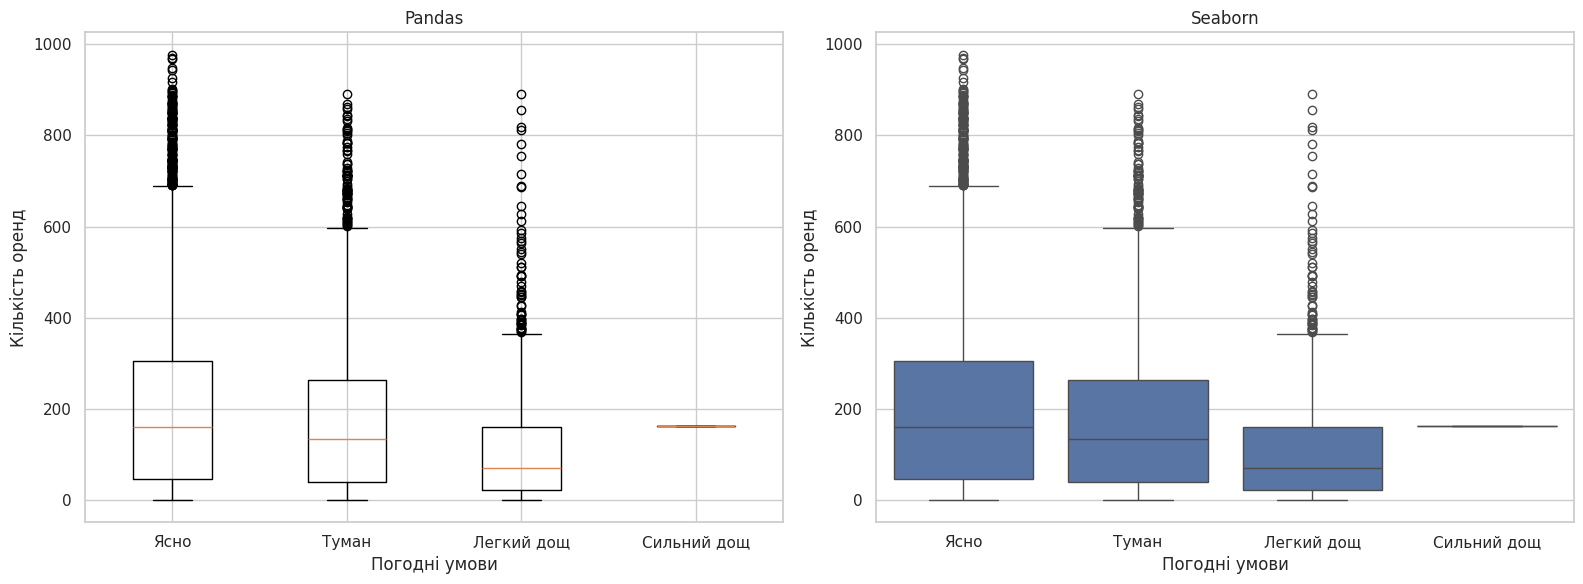

In [35]:
weather_labels = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
grouped = [df[df['weather'] == w]['count'] for w in sorted(df['weather'].unique())]
fig, axes = plt.subplots(1, 2, figsize=(16,6))
axes[0].boxplot(grouped, tick_labels=weather_labels)
axes[0].set_title('Pandas')
axes[0].set_xlabel('Погодні умови')
axes[0].set_ylabel('Кількість оренд')

sns.boxplot(x='weather', y='count', data=df, ax=axes[1])
axes[1].set_title('Seaborn')
axes[1].set_xlabel('Погодні умови')
axes[1].set_ylabel('Кількість оренд')
axes[1].set_xticks([0,1,2,3])
axes[1].set_xticklabels(weather_labels)

plt.tight_layout()
plt.show()

У seaborn коробки ширші та без додаткових налаштувань одразу кольорові.

Pandas box plot - простий, мінімалістичний, більше контролю вручну

Seaborn box plot - більш естетичний, автоматизований, зручніший для категоріальних змінних

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


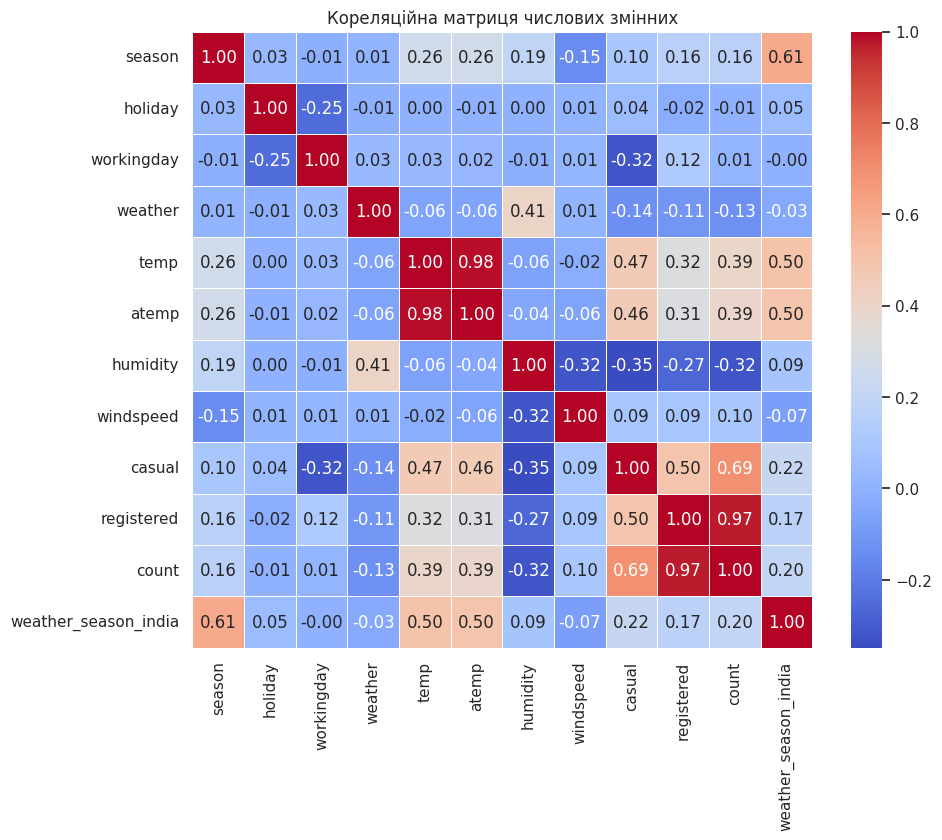

In [38]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Кореляційна матриця числових змінних')
plt.show()


1. Найсильніший зв'язок із загальною кількістю оренд (count) має registerd та casual

2. Кореляція між temp та atemp = 0.98. Тому, що atemp — це "відчутна температура", вона розраховується на основі temp з урахуванням вологості та вітру

3. Найбільш помітні негативні значення:
(humidity, count = -0.32)
(humidity, casual = -0.35)
(workingday, casual = -0.32)


## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


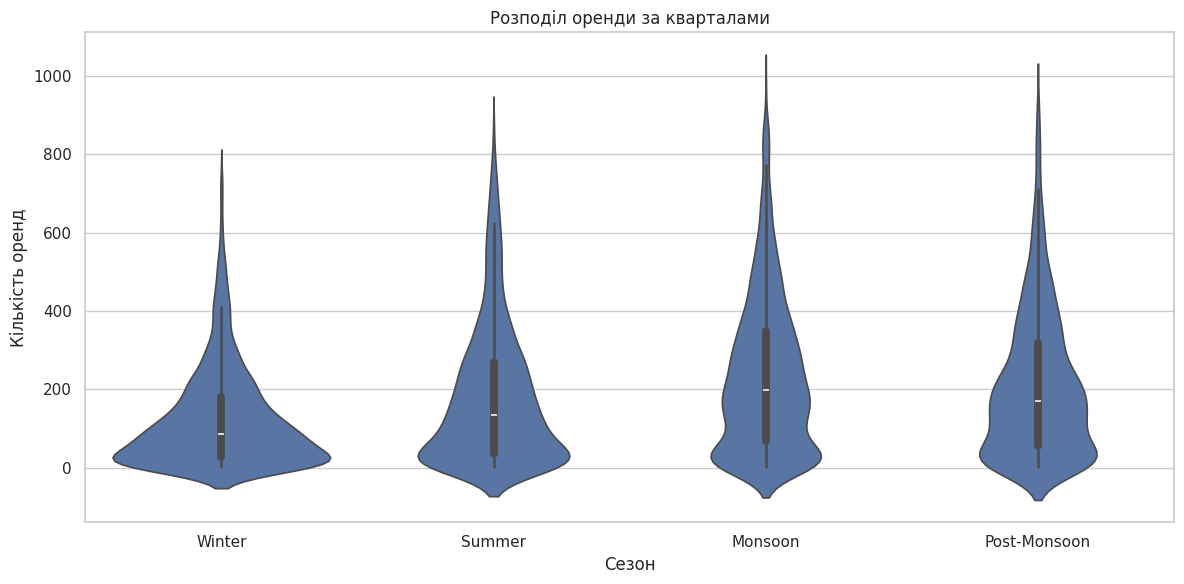

In [44]:
df['season_name'] = df['weather_season_india'].map(india_season_names)
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='season_name', y='count')
plt.title('Розподіл оренди за кварталами')
plt.tight_layout()
plt.xlabel('Сезон')
plt.ylabel('Кількість оренд')
plt.show()

1. Товщина (ширина) «скрипки» по горизонталі показує щільність розподілу ймовірності (Kernel Density Estimation). Чим ширша ділянка, тим більше значень потрапляє в цей діапазон
2. Найбільша варіабельність (розкид даних) спостерігається в кварталі Monsoon
3. Box plot показує лише статистичні зведення (мінімум, макс, медіана). Violin plot показує багатомодальність. Якби у наших даних було два «піки» (наприклад, багато дешевих оренд і багато дуже дорогих, але нічого посередині), box plot показав би просто середнє значення, а violin plot показав би «талію» (звуження) посередині, виявивши реальну структуру даних

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

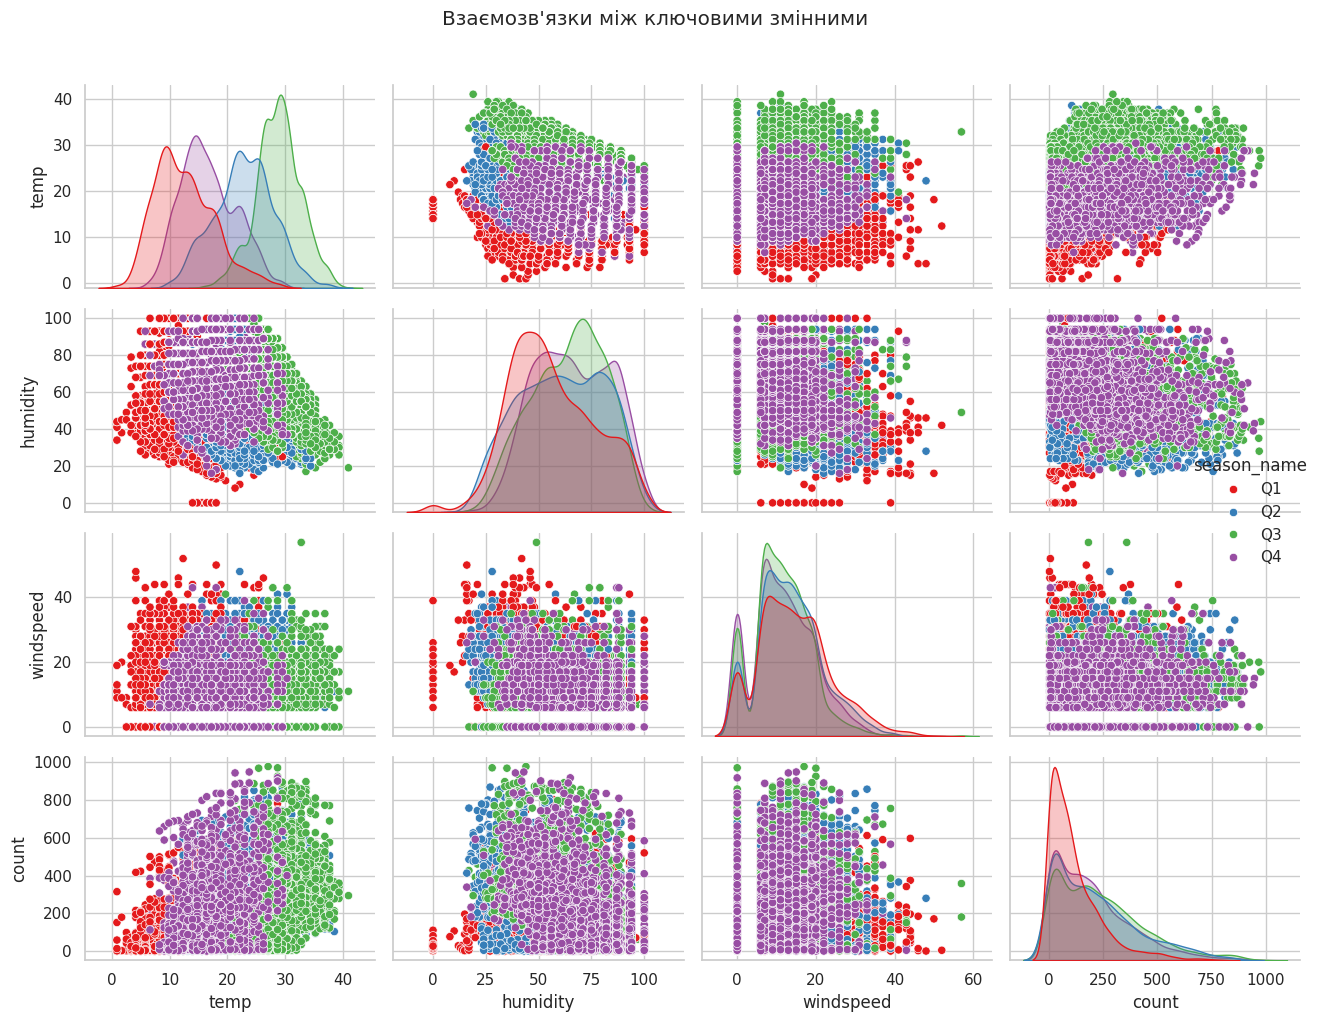

In [51]:
season_names = {
    1: 'Q1',
    2: 'Q2',
    3: 'Q3',
    4: 'Q4'
}

df['season_name'] = df['season'].map(season_names)
data_df = df[['temp', 'humidity', 'windspeed', 'count', 'season_name']]
sns.pairplot(data_df, height=2.5, aspect=1.2, hue='season_name', palette='Set1')
plt.suptitle('Взаємозв\'язки між ключовими змінними', y=1.02)
plt.tight_layout()
plt.show()

1. Найсильніша лінійна кореляція спостерігається між змінними temp (температура) та count (кількість оренд)
2. Найбільш виражена різниця між кварталами спостерігається за показником temp (температура)

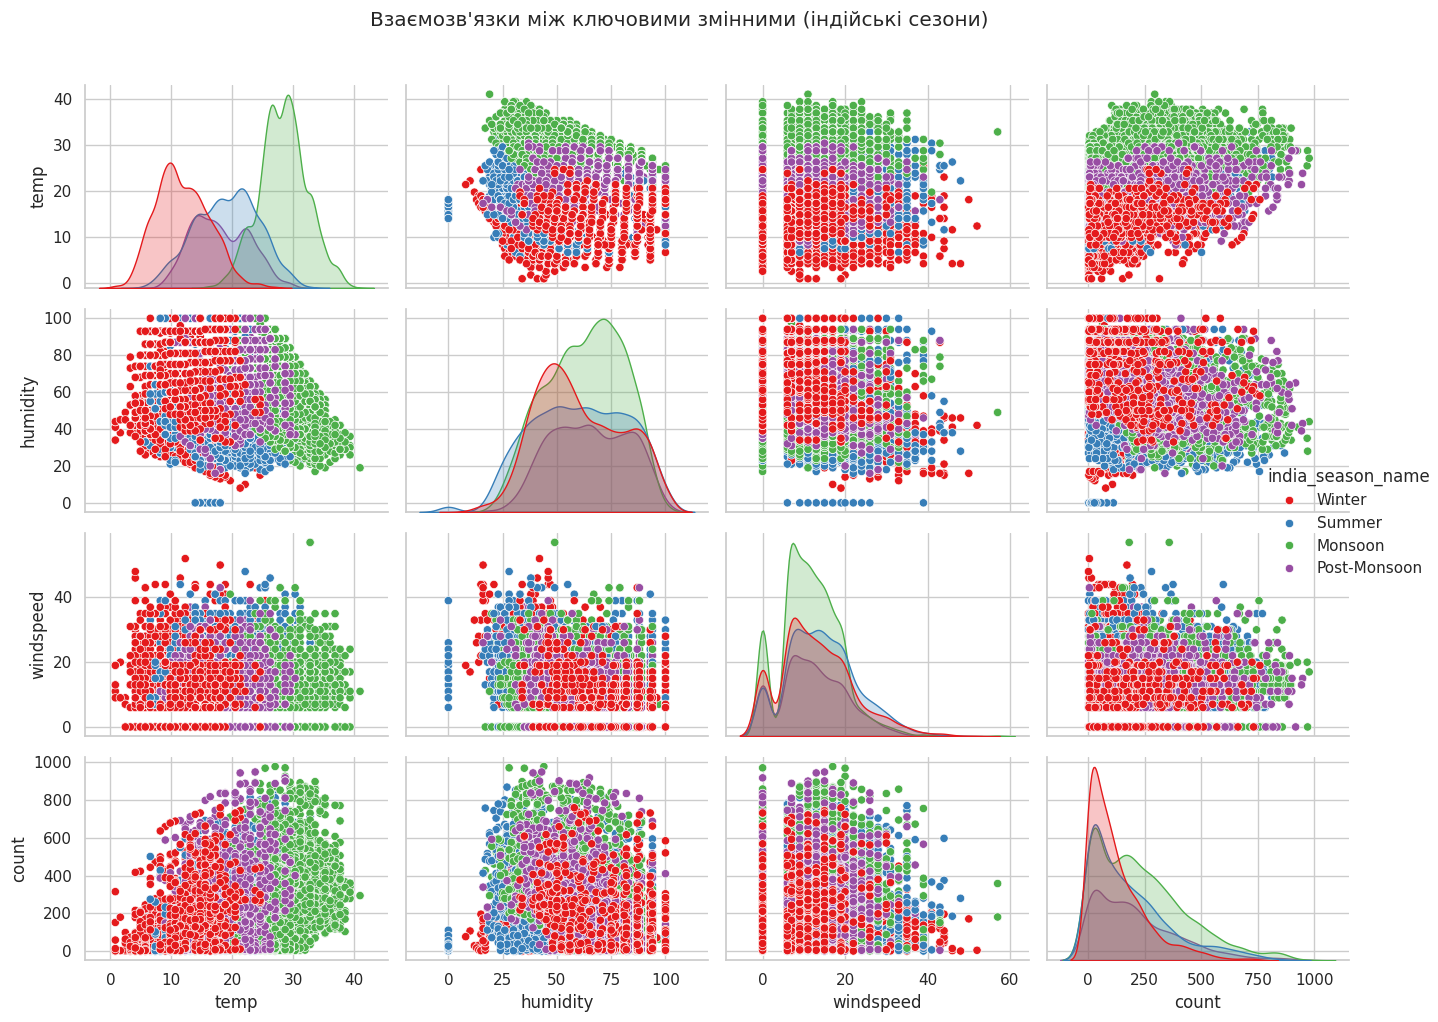

In [55]:
df['india_season_name'] = df['weather_season_india'].map(india_season_names)
data_df = df[['temp', 'humidity', 'windspeed', 'count', 'india_season_name']]
g = sns.pairplot(data_df, height=2.5, aspect=1.2, hue='india_season_name', palette='Set1')
g._legend.set_bbox_to_anchor((1.05, 0.5))
plt.suptitle('Взаємозв\'язки між ключовими змінними (індійські сезони)', y=1.02)
plt.tight_layout()
plt.show()

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

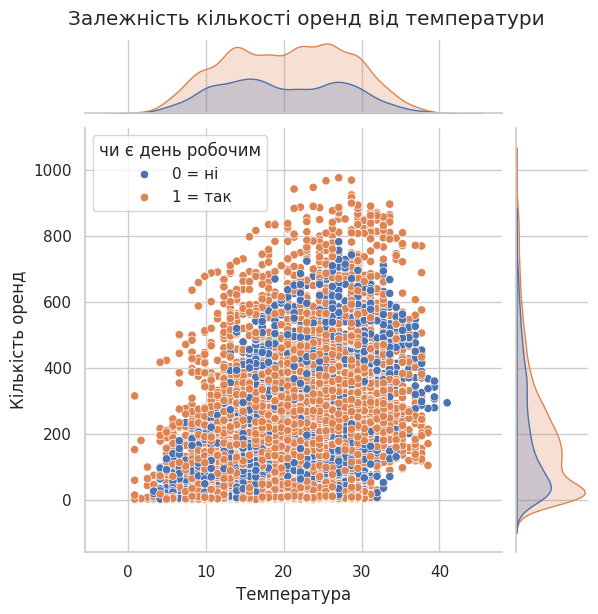

In [59]:
g = sns.jointplot(data=df, x="temp", y="count", hue="workingday", kind="scatter")
g.fig.suptitle("Залежність кількості оренд від температури", y=1.02)
g.set_axis_labels("Температура", "Кількість оренд")
new_labels = ["0 = ні", "1 = так"]
legend = g.ax_joint.legend_
for t, l in zip(legend.texts, new_labels):
    t.set_text(l)
legend.set_title("чи є день робочим")
plt.show()

1. Графіки зверху та праворуч від основної діаграми розсіювання - це одновимірні розподіли щільності (Kernel Density Estimation або KDE) для кожної змінної окремо. Верхній графік: показує розподіл температури (temp). Правий графік: показує розподіл кількості оренд (count)
2. Згідно з наданими графіками, суттєвої різниці в поведінці користувачів немає, оскільки в обидва типи днів спостерігається ідентичний висхідний тренд залежності оренди від температури. Показники щільності (KDE) по краях підтверджують, що пікові значення оренди та розподіл температур для робочих і вихідних днів майже повністю збігаються.
А кількість оренд у робочі дні є більшою